<a href="https://colab.research.google.com/github/denisadwi793/Submission/blob/main/File_kera_epi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Parameter global
mu = 0.0166879
beta = 0.112565
delta = 0.708775
alpha = 0.0164364
gamma = 0.0146969

# Fungsi turunan (dengan parameter normalisasi)
def dS_dt(S, E, I, R):
    N = S + E + I + R
    return (mu * N) - mu * S - beta * S * E / N

def dE_dt(S, E, I, R):
    N = S + E + I + R
    return beta * S * E / N - mu * E - delta * E

def dI_dt(S, E, I, R):
    return delta * E - (mu + alpha) * I - gamma * I

def dR_dt(S, E, I, R):
    return gamma * I - mu * R

# Runge-Kutta orde 4
def runge_kutta_seir(S0, E0, I0, R0, t0, t_end, h):
    num_steps = int((t_end - t0) / h) + 1
    t_values = np.linspace(t0, t_end, num_steps)
    S_values, E_values, I_values, R_values = np.zeros(num_steps), np.zeros(num_steps), np.zeros(num_steps), np.zeros(num_steps)

    S_values[0], E_values[0], I_values[0], R_values[0] = S0, E0, I0, R0

    for i in range(1, num_steps):
        S, E, I, R = S_values[i-1], E_values[i-1], I_values[i-1], R_values[i-1]

        k1_S = h * dS_dt(S, E, I, R)
        k1_E = h * dE_dt(S, E, I, R)
        k1_I = h * dI_dt(S, E, I, R)
        k1_R = h * dR_dt(S, E, I, R)

        k2_S = h * dS_dt(S + k1_S/2, E + k1_E/2, I + k1_I/2, R + k1_R/2)
        k2_E = h * dE_dt(S + k1_S/2, E + k1_E/2, I + k1_I/2, R + k1_R/2)
        k2_I = h * dI_dt(S + k1_S/2, E + k1_E/2, I + k1_I/2, R + k1_R/2)
        k2_R = h * dR_dt(S + k1_S/2, E + k1_E/2, I + k1_I/2, R + k1_R/2)

        k3_S = h * dS_dt(S + k2_S/2, E + k2_E/2, I + k2_I/2, R + k2_R/2)
        k3_E = h * dE_dt(S + k2_S/2, E + k2_E/2, I + k2_I/2, R + k2_R/2)
        k3_I = h * dI_dt(S + k2_S/2, E + k2_E/2, I + k2_I/2, R + k2_R/2)
        k3_R = h * dR_dt(S + k2_S/2, E + k2_E/2, I + k2_I/2, R + k2_R/2)

        k4_S = h * dS_dt(S + k3_S, E + k3_E, I + k3_I, R + k3_R)
        k4_E = h * dE_dt(S + k3_S, E + k3_E, I + k3_I, R + k3_R)
        k4_I = h * dI_dt(S + k3_S, E + k3_E, I + k3_I, R + k3_R)
        k4_R = h * dR_dt(S + k3_S, E + k3_E, I + k3_I, R + k3_R)

        S_values[i] = S + (k1_S + 2*k2_S + 2*k3_S + k4_S) / 6
        E_values[i] = E + (k1_E + 2*k2_E + 2*k3_E + k4_E) / 6
        I_values[i] = I + (k1_I + 2*k2_I + 2*k3_I + k4_I) / 6
        R_values[i] = R + (k1_R + 2*k2_R + 2*k3_R + k4_R) / 6

    return t_values, S_values, E_values, I_values, R_values

# Parameter awal
t0, t_end, h = 0, 50, 0.1
S0, E0, I0, R0 = 214_966_493, 24_828_522, 21_248_202, 312_283

# Simulasi
t_values, S, E, I, R = runge_kutta_seir(S0, E0, I0, R0, t0, t_end, h)

# Konversi waktu ke tahun
t_values = t_values + 2017
t_values = t_values.astype(int)

# Buat DataFrame hasil
df = pd.DataFrame({
    "Year": t_values,
    "S": S,
    "E": E,
    "I": I,
    "R": R
})

# Hapus duplikat tahun (karena h=0.1)
df = df.drop_duplicates(subset="Year").reset_index(drop=True)

# Format output agar rapi
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Tampilkan hasil dengan format ribuan
display(df.style.format({
    "S": "{:,.0f}",
    "E": "{:,.0f}",
    "I": "{:,.0f}",
    "R": "{:,.0f}"
}))



,Year,S,E,I,R
0,2017,"214,966,493","24,828,522","21,248,202","312,283"
1,2018,"214,045,810","13,183,339","32,955,905","712,995"
2,2019,"213,922,182","6,999,907","38,160,070","1,225,143"
3,2020,"214,208,348","3,717,705","39,958,869","1,777,103"
4,2021,"214,701,073","1,975,307","39,995,038","2,331,847"
5,2022,"215,293,134","1,050,028","39,138,273","2,870,661"
6,2023,"215,927,919","558,451","37,848,138","3,384,509"
7,2024,"216,575,647","297,160","36,366,699","3,869,443"
8,2025,"217,220,803","158,203","34,820,699","4,324,180"
9,2026,"217,855,457","84,266","33,275,750","4,748,811"


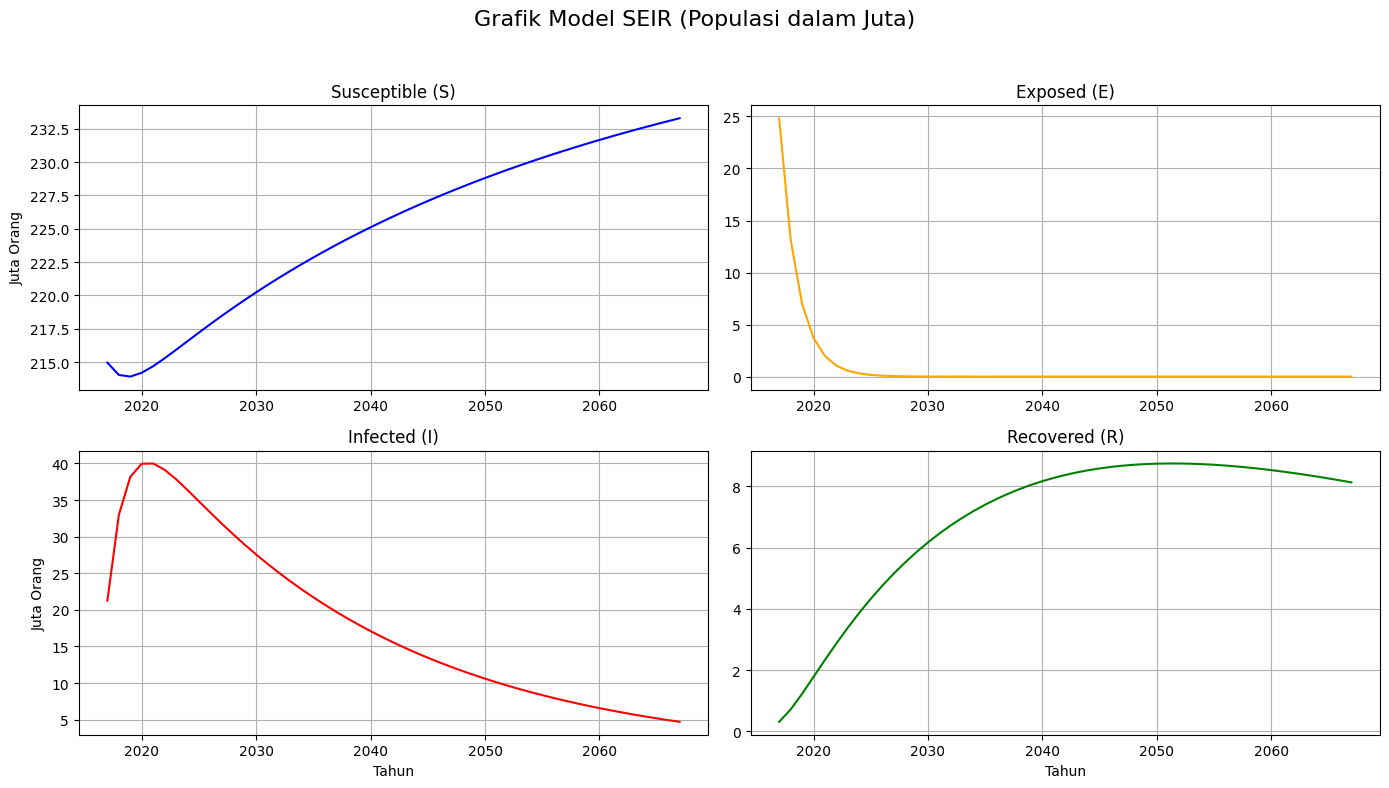

In [23]:
# Konversi ke juta biar skalanya enak dilihat
df[['S', 'E', 'I', 'R']] = df[['S', 'E', 'I', 'R']] / 1_000_000

# Buat subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Grafik Model SEIR (Populasi dalam Juta)', fontsize=16)

# Grafik S
axs[0, 0].plot(df['Year'], df['S'], color='blue')
axs[0, 0].set_title('Susceptible (S)')
axs[0, 0].set_ylabel('Juta Orang')
axs[0, 0].grid(True)

# Grafik E
axs[0, 1].plot(df['Year'], df['E'], color='orange')
axs[0, 1].set_title('Exposed (E)')
axs[0, 1].grid(True)

# Grafik I
axs[1, 0].plot(df['Year'], df['I'], color='red')
axs[1, 0].set_title('Infected (I)')
axs[1, 0].set_xlabel('Tahun')
axs[1, 0].set_ylabel('Juta Orang')
axs[1, 0].grid(True)

# Grafik R
axs[1, 1].plot(df['Year'], df['R'], color='green')
axs[1, 1].set_title('Recovered (R)')
axs[1, 1].set_xlabel('Tahun')
axs[1, 1].grid(True)

# Tata letak rapi
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



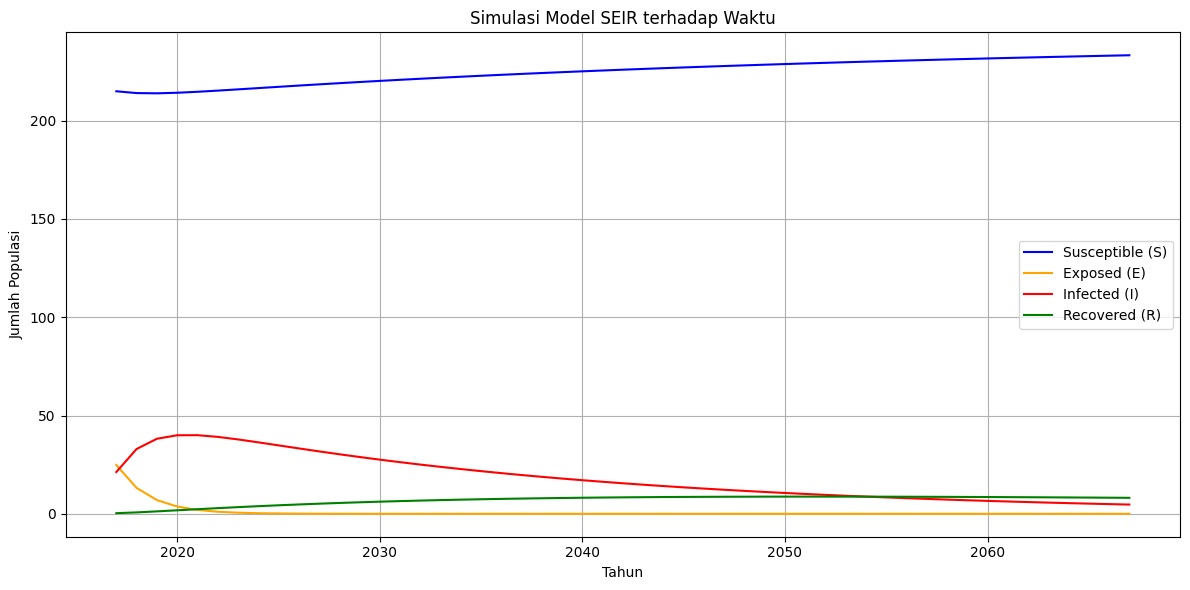

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(df['Year'], df['S'], label='Susceptible (S)', color='blue')
plt.plot(df['Year'], df['E'], label='Exposed (E)', color='orange')
plt.plot(df['Year'], df['I'], label='Infected (I)', color='red')
plt.plot(df['Year'], df['R'], label='Recovered (R)', color='green')

plt.xlabel('Tahun')
plt.ylabel('Jumlah Populasi')
plt.title('Simulasi Model SEIR terhadap Waktu')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
